In [2]:
#%pip install pandas
#%pip install numpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("C:\\Users\\Shree\\OneDrive\\Desktop\\Advanced_Multi_Source_Project\\Online_Books _Price & Rating_Analysis\\Book_cleaned_dataset1.csv")
df

,Unnamed: 0,Title,Price,Rating,In_stock,Category
0,0,A Light in the Attic,51.77,3,In stock,Poetry
1,1,Tipping the Velvet,53.74,1,In stock,Historical Fiction
2,2,Soumission,50.10,1,In stock,Fiction
3,3,Sharp Objects,47.82,4,In stock,Mystery
4,4,Sapiens: A Brief History of Humankind,54.23,5,In stock,History
...,...,...,...,...,...,...
575,575,Our Band Could Be Your Life: Scenes from the A...,57.25,3,In stock,Music
576,576,Olio,23.88,1,In stock,Poetry
577,577,Mesaerion: The Best Science Fiction Stories 18...,37.59,1,In stock,Science Fiction
578,578,Libertarianism for Beginners,51.33,2,In stock,Politics


In [4]:
# All information about dataset
df.head()
df.shape
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 580 entries, 0 to 579
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  580 non-null    int64  
 1   Title       580 non-null    object 
 2   Price       580 non-null    float64
 3   Rating      580 non-null    int64  
 4   In_stock    580 non-null    object 
 5   Category    580 non-null    object 
dtypes: float64(1), int64(2), object(3)
memory usage: 27.3+ KB


Index(['Unnamed: 0', 'Title', 'Price', 'Rating', 'In_stock', 'Category'], dtype='object')

In [5]:
#All column names
df.columns

Index(['Unnamed: 0', 'Title', 'Price', 'Rating', 'In_stock', 'Category'], dtype='object')

In [6]:
# check the categorical values
category_counts = df["Category"].value_counts()
category_counts

Category
Poetry                116
Default                87
Young Adult            58
Music                  58
Historical Fiction     29
Fiction                29
Mystery                29
History                29
Business               29
Sequential Art         29
Science Fiction        29
Politics               29
Travel                 29
Name: count, dtype: int64

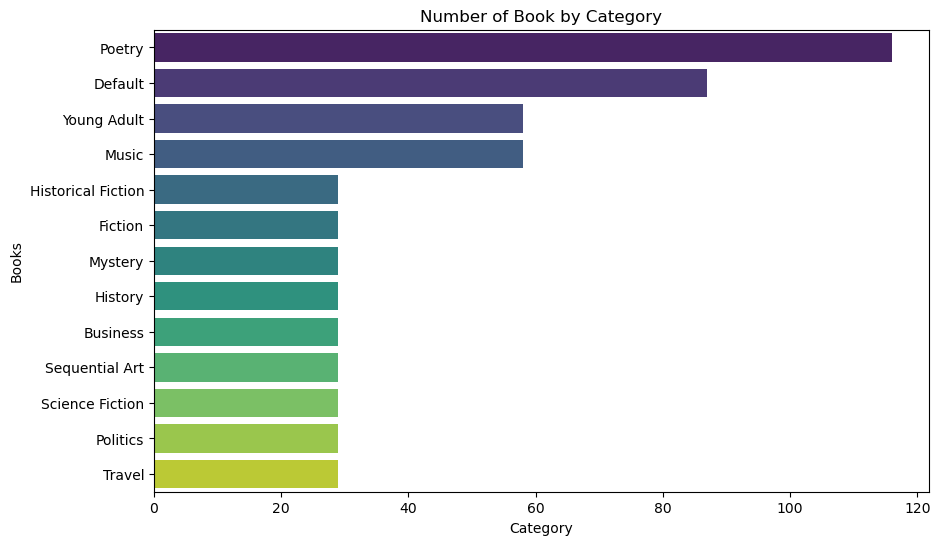

In [7]:
plt.figure(figsize=(10,6))
sns.barplot( x = category_counts.values,
            y = category_counts.index,
            hue= category_counts.index,
            palette="viridis",)
plt.title("Number of Book by Category")
plt.xlabel("Category")
plt.ylabel("Books")
plt.show()

C:\Users\Shree\AppData\Local\Temp\ipykernel_27304\488100545.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data = df,


Text(0, 0.5, 'Books')

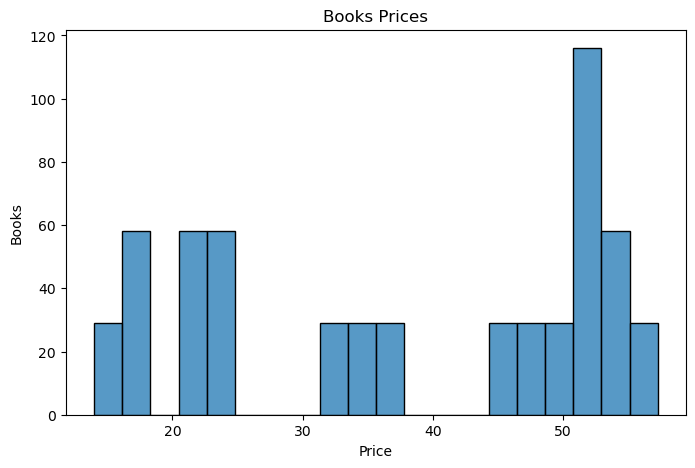

In [8]:
# Price Distribution
plt.figure(figsize=(8,5))

sns.histplot(data = df,
             x = "Price",
             bins = 20,
             palette = "set2")
plt.title("Books Prices")
plt.xlabel("Price")
plt.ylabel("Books")

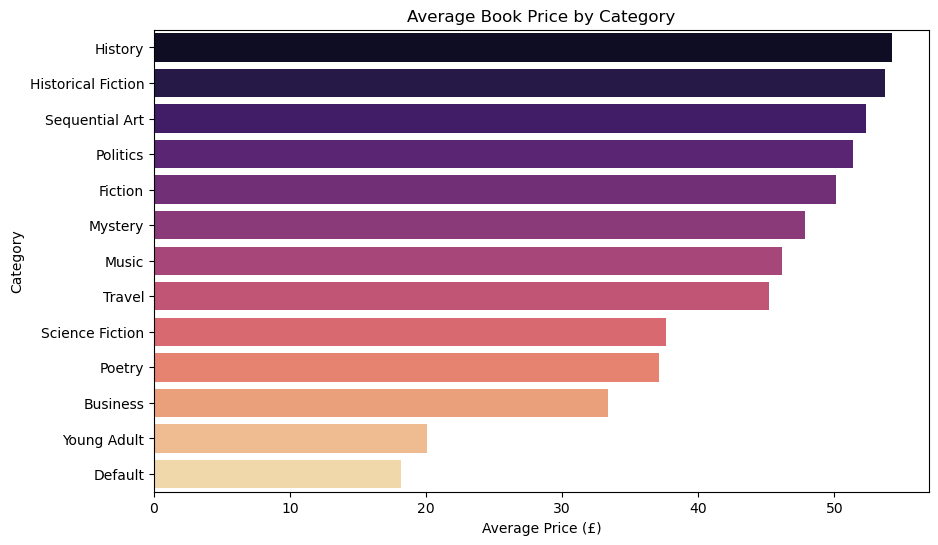

In [9]:
# Average Price by Category

avg_price = (
    df.groupby("Category")["Price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=avg_price.values,
    y=avg_price.index,
    hue=avg_price.index,
    palette="magma",
    legend=False
)

plt.title("Average Book Price by Category")
plt.xlabel("Average Price (£)")
plt.ylabel("Category")

plt.show()


Rating
1    174
2     87
3     87
4    116
5    116
Name: count, dtype: int64


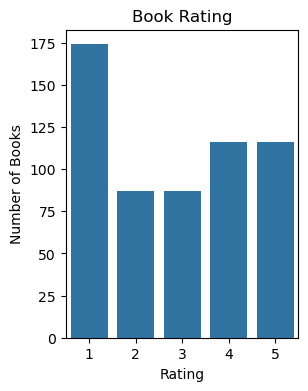

In [10]:
# Rating distribution

rating_counts = df["Rating"].value_counts().sort_index()
print(rating_counts)

plt.figure(figsize=(3,4))
sns.countplot(data = df,
              x = "Rating")
plt.title("Book Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.show()


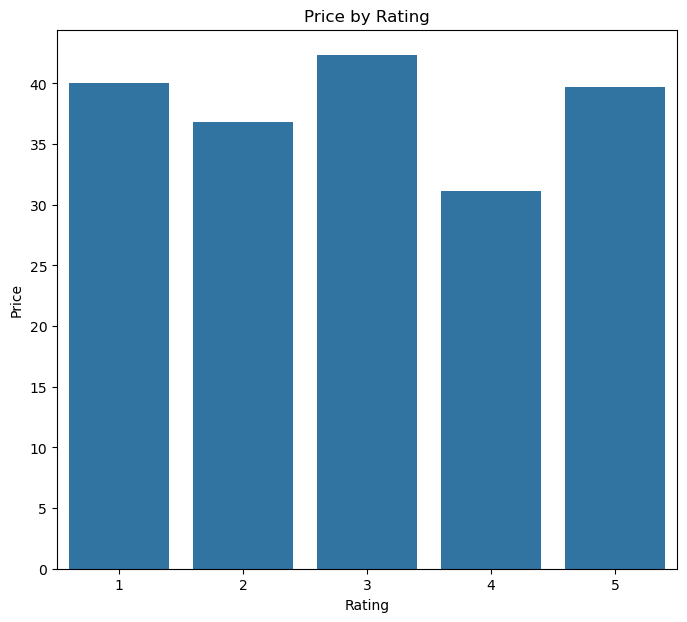

In [11]:
# Average price by rating 

avg_price_rating = (df.groupby("Rating")["Price"].mean())
plt.figure(figsize=(8,7))
sns.barplot(x = avg_price_rating.index,
            y = avg_price_rating.values,
            )
plt.title("Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Price")
plt.show()

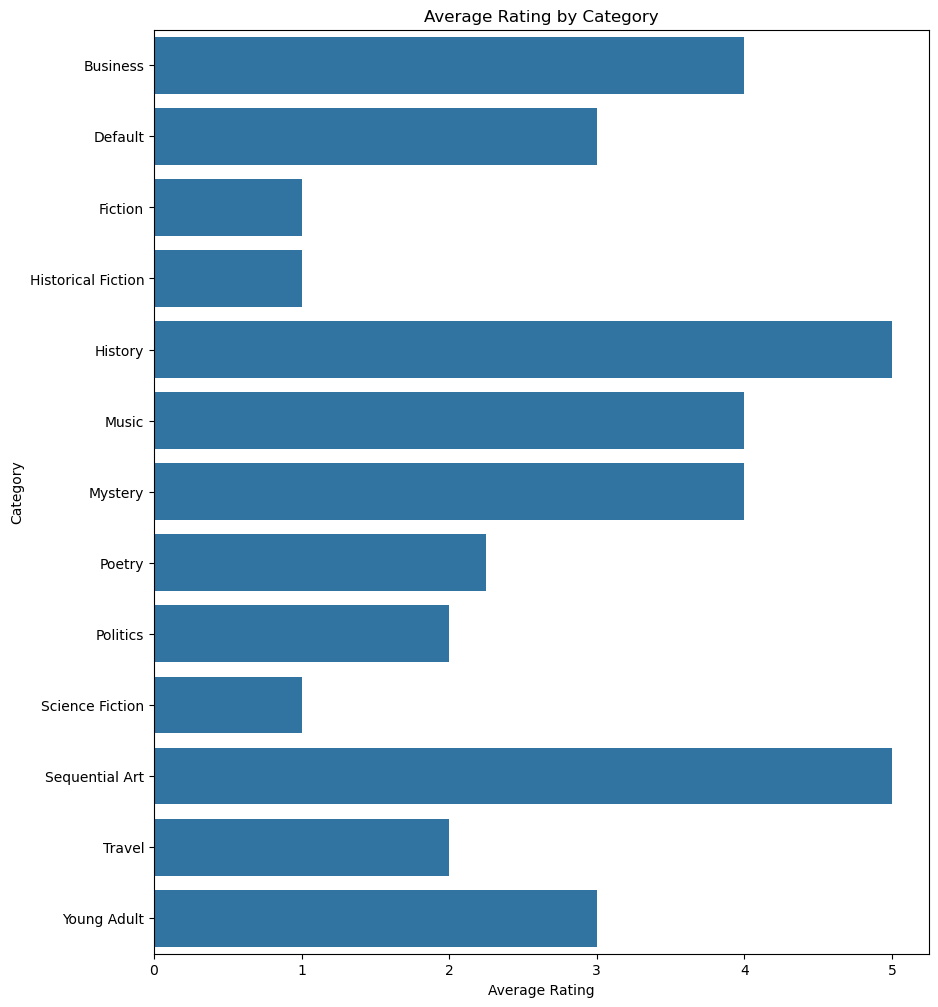

In [12]:
# Category Vs Rating

category_rating = (df.groupby("Category")["Rating"].mean())
plt.figure(figsize=(10,12))
sns.barplot(x = category_rating.values,
            y = category_rating.index)
plt.title("Average Rating by Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.show()


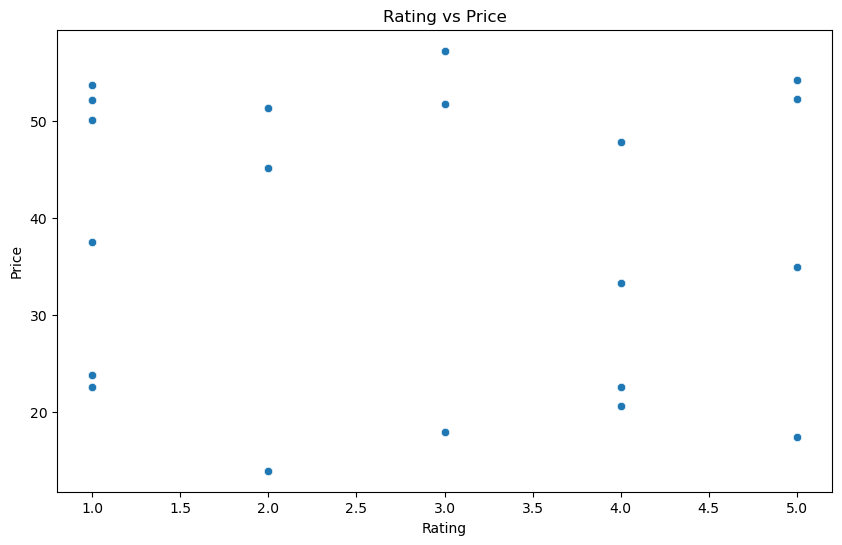

In [13]:
# Price vs Rating 

plt.figure(figsize=(10,6))
sns.scatterplot(data = df,
                x = "Rating",
                y = "Price")
plt.title("Rating vs Price")
plt.xlabel("Rating")
plt.ylabel("Price")
plt.show()

In [14]:
# Top Rated books 
top_rated_books = (
    df.sort_values(by="Rating", ascending=False)
      [["Title", "Rating", "Price", "Category"]]
      .head(10)
)

print(top_rated_books)

                                                 Title  Rating  Price  \
352                                        Set Me Free       5  17.46   
373  Scott Pilgrim's Precious Little Life (Scott Pi...       5  52.29   
133  Scott Pilgrim's Precious Little Life (Scott Pi...       5  52.29   
134                          Rip it Up and Start Again       5  35.02   
494                          Rip it Up and Start Again       5  35.02   
493  Scott Pilgrim's Precious Little Life (Scott Pi...       5  52.29   
492                                        Set Me Free       5  17.46   
144              Sapiens: A Brief History of Humankind       5  54.23   
392                                        Set Me Free       5  17.46   
484              Sapiens: A Brief History of Humankind       5  54.23   

           Category  
352     Young Adult  
373  Sequential Art  
133  Sequential Art  
134           Music  
494           Music  
493  Sequential Art  
492     Young Adult  
144         History 

In [15]:
df

,Unnamed: 0,Title,Price,Rating,In_stock,Category
0,0,A Light in the Attic,51.77,3,In stock,Poetry
1,1,Tipping the Velvet,53.74,1,In stock,Historical Fiction
2,2,Soumission,50.10,1,In stock,Fiction
3,3,Sharp Objects,47.82,4,In stock,Mystery
4,4,Sapiens: A Brief History of Humankind,54.23,5,In stock,History
...,...,...,...,...,...,...
575,575,Our Band Could Be Your Life: Scenes from the A...,57.25,3,In stock,Music
576,576,Olio,23.88,1,In stock,Poetry
577,577,Mesaerion: The Best Science Fiction Stories 18...,37.59,1,In stock,Science Fiction
578,578,Libertarianism for Beginners,51.33,2,In stock,Politics


In [16]:
df.to_csv("EDA_Cleaned_File1.csv")
print("EDA File is Done Sucessfully")

EDA File is Done Sucessfully
